Parameter Estimation and Model-Based Optimal Experimental Design

## Description
This repository contains a Jupyter Lab computational workflow designed for advanced university instruction in bioprocess engineering. It demonstrates the complete cycle of kinetic parameter identification, statistical validation, and model-based optimal experimental design (OED) for a bimolecular reaction system. 

The notebook bridges the gap between theoretical mathematical concepts and their numerical implementation, providing a rigorous framework for evaluating and minimizing parameter uncertainty.

## Core Modules
* **Forward Sensitivity Analysis:** Formulation and integration of the extended ordinary differential equation system to analytically supply the Jacobian matrix to the optimization algorithm.
* **Numerical Jacobian Validation:** Precise error quantification of the analytical Jacobian against Forward Finite Differences, Central Finite Differences, and Complex Step Differentiation.
* **Statistical Inference:** Evaluation of parameter uncertainty through variance-covariance matrices, 2D linear approximation confidence ellipses, and empirical Monte Carlo distributions.
* **Optimal Experimental Design:** Implementation of D-optimal and E-optimal design criteria using a continuous relaxation approach. The workflow utilizes the Sequential Least SQuares Programming (SLSQP) algorithm coupled with Complex Step Differentiation to efficiently optimize both the discrete sampling schedule and the initial substrate concentrations.

## Dependencies
The execution of the Jupyter Notebook requires a standard scientific Python environment. 
* Python 3.8+
* Jupyter Lab
* NumPy
* SciPy
* Matplotlib

## Usage
The script is structured sequentially. Execute the cells in order to generate the synthetic data, perform the base parameter estimation, validate the numerical methods, and run the optimization for the new experimental design.

## Author and Terms of Use
**Author:** Charlotte Deffur

If you intend to utilize this material for academic teaching, research, or any commercial application, please contact me to request explicit permission prior to use.

# Introduction and Mathematical Framework: Parameter Estimation and Sensitivity Analysis
This exercise focuses on the precise estimation of kinetic parameters for a bimolecular reaction network. We utilize sensitivity equations to analytically provide the Jacobian matrix to the Levenberg-Marquardt optimizer.

The reaction network consists of two parallel reactions:

$$
\begin{align}
2A + B &\xrightarrow{k_1} P_1 \\
A + B &\xrightarrow{k_2} P_2
\end{align}
$$

The corresponding ordinary differential equations for the substrates A and B are formulated as:

$$
\begin{align}
\frac{dA}{dt} &= -2k_1 A^2 B - k_2 AB \\
\frac{dB}{dt} &= -k_1 A^2 B - k_2 AB
\end{align}
$$
To estimate the parameters $k_1$ and $k_2$, we minimize a cost function $\phi$, which is defined as the sum of squared differences between the measured experimental data $\hat{x}_i$ and the model predictions $x(p, t_i)$ over $N$ time points. The mathematically exact optimal parameters are found where the first derivative of the cost function with respect to the parameters equals zero. 

To locate this optimum, optimization algorithms require the Jacobian matrix, which contains the first-order partial derivatives of the model predictions with respect to the parameters. In this context:
* $x$ denotes the state vector (the concentrations $A$ and $B$).
* $f$ represents the right-hand side of the ordinary differential equation system (the kinetic rate laws).
* $p_k$ is the $k$-th kinetic parameter to be estimated.

Calculating the Jacobian requires the parameter sensitivities $\sigma_k = \frac{dx}{dp_k}$. The dynamic evolution of these sensitivities is obtained by differentiating the model equations $\frac{dx}{dt} = f(x, p, t)$ with respect to the parameters. Applying the chain rule yields a new set of differential equations:

$$
\frac{d}{dt}\frac{dx}{dp_k} = \frac{\partial f}{\partial x}\frac{dx}{dp_k} + \frac{\partial f}{\partial p_k}
$$

To derive the sensitivity equations systematically, we first define the right-hand sides of the ordinary differential equations as functions $f_1$ and $f_2$:

$$
\begin{align}
f_1 &= -2k_1 A^2 B - k_2 AB \\
f_2 &= -k_1 A^2 B - k_2 AB
\end{align}
$$

For the parameter $k_1$, we define the sensitivities as $\sigma_{A_1} = \frac{dA}{dk_1}$ and $\sigma_{B_1} = \frac{dB}{dk_1}$. Applying the chain rule to the time derivatives of $A$ and $B$ with respect to $k_1$ yields the explicit formulation. Since the time derivative and the parameter derivative commute, the derivation for $\sigma_{A_1}$ evaluates to:

$$
\begin{align}
\frac{d}{dk_1}\left(\frac{dA}{dt}\right) &= \frac{d}{dt}\left(\frac{dA}{dk_1}\right) = \frac{d\sigma_{A_1}}{dt} \\
&= \frac{\partial f_1}{\partial k_1} + \frac{\partial f_1}{\partial A}\sigma_{A_1} + \frac{\partial f_1}{\partial B}\sigma_{B_1} \\
&= -2A^2B - (4k_1AB + k_2B)\sigma_{A_1} - (2k_1A^2 + k_2A)\sigma_{B_1}
\end{align}
$$

Applying the exact same logic to species $B$ provides the dynamic evolution for $\sigma_{B_1}$:

$$
\begin{align}
\frac{d}{dk_1}\left(\frac{dB}{dt}\right) &= \frac{d\sigma_{B_1}}{dt} \\
&= \frac{\partial f_2}{\partial k_1} + \frac{\partial f_2}{\partial A}\sigma_{A_1} + \frac{\partial f_2}{\partial B}\sigma_{B_1} \\
&= -A^2B - (2k_1AB + k_2B)\sigma_{A_1} - (k_1A^2 + k_2A)\sigma_{B_1}
\end{align}
$$

The identical structural procedure is necessary to derive the sensitivities with respect to the second parameter $k_2$. Defining $\sigma_{A_2} = \frac{dA}{dk_2}$ and $\sigma_{B_2} = \frac{dB}{dk_2}$, the equations are constructed as follows:

$$
\begin{align}
\frac{d}{dk_2}\left(\frac{dA}{dt}\right) &= \frac{d\sigma_{A_2}}{dt} \\
&= \frac{\partial f_1}{\partial k_2} + \frac{\partial f_1}{\partial A}\sigma_{A_2} + \frac{\partial f_1}{\partial B}\sigma_{B_2} \\
&= -AB - (4k_1AB + k_2B)\sigma_{A_2} - (2k_1A^2 + k_2A)\sigma_{B_2}
\end{align}
$$

$$
\begin{align}
\frac{d\sigma_{B_2}}{dt} &= \frac{\partial f_2}{\partial k_2} + \frac{\partial f_2}{\partial A}\sigma_{A_2} + \frac{\partial f_2}{\partial B}\sigma_{B_2} \\
&= -AB - (2k_1AB + k_2B)\sigma_{A_2} - (k_1A^2 + k_2A)\sigma_{B_2}
\end{align}
$$

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import t
import matplotlib.pyplot as plt
from typing import Tuple, Dict

def base_reaction_system(time: float, y: np.ndarray, p: np.ndarray) -> list:
    """
    Evaluates the base system of ordinary differential equations.
    """
    A, B = y
    k1, k2 = p
    
    dA_dt = -2 * k1 * (A**2) * B - k2 * A * B
    dB_dt = -k1 * (A**2) * B - k2 * A * B
    
    return [dA_dt, dB_dt]

def extended_reaction_system(time: float, y: np.ndarray, p: np.ndarray) -> list:
    """
    Evaluates the extended ODE system including mass balances and forward sensitivities.
    """
    A, B, sA1, sB1, sA2, sB2 = y
    k1, k2 = p
    
    dA_dt = -2 * k1 * (A**2) * B - k2 * A * B
    dB_dt = -k1 * (A**2) * B - k2 * A * B
    
    dsA1_dt = -2*(A**2)*B - (4*k1*A*B + k2*B)*sA1 - (2*k1*(A**2) + k2*A)*sB1
    dsB1_dt = -(A**2)*B - (2*k1*A*B + k2*B)*sA1 - (k1*(A**2) + k2*A)*sB1
    
    dsA2_dt = -A*B - (4*k1*A*B + k2*B)*sA2 - (2*k1*(A**2) + k2*A)*sB2
    dsB2_dt = -A*B - (2*k1*A*B + k2*B)*sA2 - (k1*(A**2) + k2*A)*sB2
    
    return [dA_dt, dB_dt, dsA1_dt, dsB1_dt, dsA2_dt, dsB2_dt]

def simulate_base_model(p: np.ndarray, t_eval: np.ndarray, y0: np.ndarray) -> np.ndarray:
    sol = solve_ivp(
        fun=lambda t, y: base_reaction_system(t, y, p),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        method='BDF',
        rtol=1e-10,
        atol=1e-12
    )
    return sol.y.flatten()

def jacobian_analytical(p: np.ndarray, t_eval: np.ndarray, y0_base: np.ndarray) -> np.ndarray:
    y0_ext = np.array([y0_base[0], y0_base[1], 0.0, 0.0, 0.0, 0.0])
    
    sol = solve_ivp(
        fun=lambda t, y: extended_reaction_system(t, y, p),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0_ext,
        t_eval=t_eval,
        method='BDF',
        rtol=1e-10,
        atol=1e-12
    )
    
    sA1, sB1 = sol.y[2], sol.y[3]
    sA2, sB2 = sol.y[4], sol.y[5]
    
    m_obs = len(t_eval) * 2
    n_params = len(p)
    jac = np.zeros((m_obs, n_params))
    
    jac[:, 0] = np.concatenate((sA1, sB1)) 
    jac[:, 1] = np.concatenate((sA2, sB2)) 
    
    return jac

### Numerical Approximation of the Jacobian

Analytical derivation of sensitivity equations is rigorous but scales poorly with highly complex reaction networks. In such instances, numerical approximations of the Jacobian matrix become mandatory.

The foundation for finite difference methods is the Taylor series expansion of a function $x$ around a parameter value $\theta_k$ with a perturbation step size $h$:

$$
\begin{align}
x(\theta_k + h) &= x(\theta_k) + h \left.\frac{dx}{d\theta}\right|_{\theta_k} + \frac{h^2}{2} \left.\frac{d^2x}{d\theta^2}\right|_{\theta_k} + \frac{h^3}{6} \left.\frac{d^3x}{d\theta^3}\right|_{\theta_k} + \dots \\
x(\theta_k - h) &= x(\theta_k) - h \left.\frac{dx}{d\theta}\right|_{\theta_k} + \frac{h^2}{2} \left.\frac{d^2x}{d\theta^2}\right|_{\theta_k} - \frac{h^3}{6} \left.\frac{d^3x}{d\theta^3}\right|_{\theta_k} + \dots
\end{align}
$$

Rearranging the first equation yields the forward finite difference approximation, which carries a truncation error of $\mathcal{O}(h)$:

$$
\left.\frac{dx}{d\theta}\right|_{\theta_k} = \frac{x(\theta_k + h) - x(\theta_k)}{h} + \mathcal{O}(h)
$$

Subtracting the second Taylor expansion from the first eliminates the second-order derivative term. This results in the central finite difference method, which improves the truncation error to $\mathcal{O}(h^2)$:

$$
\left.\frac{dx}{d\theta}\right|_{\theta_k} = \frac{x(\theta_k + h) - x(\theta_k - h)}{2h} + \mathcal{O}(h^2)
$$

A critical limitation of both finite difference approaches is subtractive cancellation. Minimizing the truncation error theoretically requires a step size $h$ approaching zero. However, subtracting two nearly identical floating-point numbers in the numerator leads to severe round-off errors, heavily corrupting the numerical solution. 

The complex step differentiation method elegantly resolves this numerical conflict. By substituting the real step size $h$ with an imaginary step $ih$ (where $i^2 = -1$), the Taylor series expansion evaluates to:

$$
x(\theta_k + ih) = x(\theta_k) + ih \left.\frac{dx}{d\theta}\right|_{\theta_k} - \frac{h^2}{2} \left.\frac{d^2x}{d\theta^2}\right|_{\theta_k} - i\frac{h^3}{6} \left.\frac{d^3x}{d\theta^3}\right|_{\theta_k} + \dots
$$

Isolating the imaginary part $Im$ of this equation and dividing by $h$ gives:

$$
\frac{Im[x(\theta_k + ih)]}{h} = \left.\frac{dx}{d\theta}\right|_{\theta_k} - \frac{h^2}{6} \left.\frac{d^3x}{d\theta^3}\right|_{\theta_k} + \dots
$$

Rearranging this expression provides the final derivative approximation:

$$
\left.\frac{dx}{d\theta}\right|_{\theta_k} = \frac{Im[x(\theta_k + ih)]}{h} + \mathcal{O}(h^2)
$$

This formulation achieves a truncation error of $\mathcal{O}(h^2)$ without any subtraction operation in the numerator. Consequently, $h$ can be chosen near the machine epsilon, granting near-analytical precision without being compromised by subtractive cancellation.

In [3]:
def jacobian_ffd(p: np.ndarray, t_eval: np.ndarray, y0: np.ndarray) -> np.ndarray:
    n_params = len(p)
    y_ref = simulate_base_model(p, t_eval, y0)
    jac = np.zeros((len(y_ref), n_params))
    h = np.sqrt(np.finfo(float).eps)
    
    for k in range(n_params):
        p_step = p.copy()
        p_step[k] += h
        y_step = simulate_base_model(p_step, t_eval, y0)
        jac[:, k] = (y_step - y_ref) / h
    return jac

def jacobian_cfd(p: np.ndarray, t_eval: np.ndarray, y0: np.ndarray) -> np.ndarray:
    n_params = len(p)
    m_obs = len(simulate_base_model(p, t_eval, y0))
    jac = np.zeros((m_obs, n_params))
    h = np.finfo(float).eps ** (1/3)
    
    for k in range(n_params):
        p_fw, p_bw = p.copy(), p.copy()
        p_fw[k] += h
        p_bw[k] -= h
        y_fw = simulate_base_model(p_fw, t_eval, y0)
        y_bw = simulate_base_model(p_bw, t_eval, y0)
        jac[:, k] = (y_fw - y_bw) / (2 * h)
    return jac

def jacobian_csd(p: np.ndarray, t_eval: np.ndarray, y0: np.ndarray) -> np.ndarray:
    n_params = len(p)
    m_obs = len(simulate_base_model(p, t_eval, y0))
    jac = np.zeros((m_obs, n_params))
    h = np.finfo(float).eps
    
    y0_complex = np.array(y0, dtype=complex)
    
    for k in range(n_params):
        p_step = p.astype(complex).copy()
        p_step[k] += h * 1j
        y_step = simulate_base_model(p_step, t_eval, y0_complex)
        jac[:, k] = np.imag(y_step) / h
    return jac

### Parameter Estimation and Statistical Inference

Following the numerical determination of the optimal parameter set, a rigorous statistical validation is imperative to quantify the accuracy and reliability of the estimates. For nonlinear models, the parameter variance-covariance matrix $V$ is typically evaluated utilizing a linear approximation based on a first-order Taylor series expansion:

$$
V = (J^T J)^{-1} s^2
$$

where $J$ denotes the Jacobian matrix containing the local sensitivity coefficients evaluated at the optimal parameter set, and $s^2$ represents the estimated variance of the measurement errors.

The diagonal elements of the variance-covariance matrix, $V_{ii}$, correspond to the variance of the individual parameter estimates. These specific values are computationally essential for constructing the linear approximation confidence intervals and joint confidence regions, which statistically bound the true parameter values. It must be noted that for highly nonlinear systems, this linear approximation may underestimate the true confidence regions, requiring structural verification.

Crucially, this sensitivity framework establishes a direct theoretical link to model-based optimal experimental design. According to the Cramér-Rao bound, the inverse of the Fisher Information Matrix ($FIM$) constitutes the best possible covariance matrix, acting as a lower bound, for any unbiased Maximum Likelihood (ML) estimator. For a model with independent, normally distributed measurement errors having an expected value of zero and a variance of $\sigma^2$, the estimation obtained via the method of least squares equals the Maximum Likelihood estimation, and one can use the following approximation:

$$
FIM \approx V^{-1}
$$

In the context of optimal experimental design, scalar metrics of this information matrix (such as its determinant for D-optimal design) are mathematically maximized. This optimization systematically identifies the experimental conditions that will yield the maximum possible information content in future experiments, thereby minimizing subsequent parameter uncertainty.

### Methodological Approach: Validation of the Estimation Algorithm

To verify the reliability and numerical accuracy of the parameter estimation, an *in silico* experiment is conducted. This approach allows for an objective comparison of the estimation results against a known reference state. The workflow comprises four central steps:

1. **Generation of synthetic data:** First, the model is simulated using exactly defined ("true") parameters. To replicate real laboratory conditions, these ideal trajectories are superimposed with normally distributed noise. This provides a dataset with known true parameters that serves as an objective benchmark.
2. **Parameter estimation:** Starting from initial guesses, a Levenberg-Marquardt optimizer searches for the parameter vector that minimizes the sum of squared residuals between the model predictions and the noisy data. The algorithm utilizes the analytically calculated Jacobian matrix to converge efficiently to the minimum.
3. **Statistical evaluation:** Convergence alone does not guarantee reliable parameters. Therefore, the calculated Jacobian matrix at the optimum is used to determine the covariance matrix and the resulting confidence intervals. The quality of the estimation is validated by checking whether the true parameters fall within the calculated confidence intervals of the estimated parameters.
4. **Numerical validation of the Jacobian:** Since the derivation and implementation of analytical sensitivity equations are prone to errors, the resulting Jacobian matrix is rigorously tested. It is evaluated at the optimum and compared against three numerical approximations (forward finite difference, central finite difference, and complex step differentiation). The discrepancy is quantified using a matrix norm.

In [6]:
def residuals_fun(p: np.ndarray, t_eval: np.ndarray, y_exp_flat: np.ndarray, y0: np.ndarray) -> np.ndarray:
    y_sim_flat = simulate_base_model(p, t_eval, y0)
    return y_sim_flat - y_exp_flat

def jacobian_fun(p: np.ndarray, t_eval: np.ndarray, y_exp_flat: np.ndarray, y0: np.ndarray) -> np.ndarray:
    return jacobian_analytical(p, t_eval, y0)

# Daten generieren
p_true = np.array([0.5, 1.2])
y0_base = np.array([1.0, 1.0])
t_eval = np.linspace(0, 10, 20) # 20 points in time

y_true_flat = simulate_base_model(p_true, t_eval, y0_base)

np.random.seed(42)
noise_level = 0.05
y_noisy_flat = y_true_flat + np.random.normal(0, noise_level, y_true_flat.shape)

# Parameterschätzung
p_guess = np.array([0.1, 0.1])

res = least_squares(
    fun=residuals_fun,
    x0=p_guess,
    jac=jacobian_fun,
    args=(t_eval, y_noisy_flat, y0_base),
    method='lm'
)

p_est = res.x

# Statistische Analyse
dof = max(0, len(y_noisy_flat) - len(p_est))
mse = np.sum(res.fun**2) / dof

J_opt = res.jac 
cov_matrix = mse * np.linalg.inv(J_opt.T @ J_opt)

standard_errors = np.sqrt(np.diagonal(cov_matrix))
t_val = t.ppf(1.0 - 0.05 / 2.0, dof)
ci_half_width = t_val * standard_errors

print("--- Parameter Estimation Results ---")
print(f"k1: True = {p_true[0]:.4f} | Est = {p_est[0]:.4f} +/- {ci_half_width[0]:.4f}")
print(f"k2: True = {p_true[1]:.4f} | Est = {p_est[1]:.4f} +/- {ci_half_width[1]:.4f}")
print("\n")

# Validierung der Jacobi-Matrix
J_ana = jacobian_analytical(p_est, t_eval, y0_base)
J_ffd = jacobian_ffd(p_est, t_eval, y0_base)
J_cfd = jacobian_cfd(p_est, t_eval, y0_base)
J_csd = jacobian_csd(p_est, t_eval, y0_base)

err_ffd = np.linalg.norm(J_ana - J_ffd, ord='fro') #Frobenius norm
err_cfd = np.linalg.norm(J_ana - J_cfd, ord='fro')
err_csd = np.linalg.norm(J_ana - J_csd, ord='fro')

print("--- Jacobian Approximation Errors ---")
print(f"Forward Finite Difference Error: {err_ffd:.4e}")
print(f"Central Finite Difference Error: {err_cfd:.4e}")
print(f"Complex Step Differentiation Error: {err_csd:.4e}")

--- Parameter Estimation Results ---
k1: True = 0.5000 | Est = 0.4347 +/- 0.1515
k2: True = 1.2000 | Est = 1.2912 +/- 0.1763


--- Jacobian Approximation Errors ---
Forward Finite Difference Error: 7.9976e-08
Central Finite Difference Error: 1.4504e-09
Complex Step Differentiation Error: 4.4172e-09


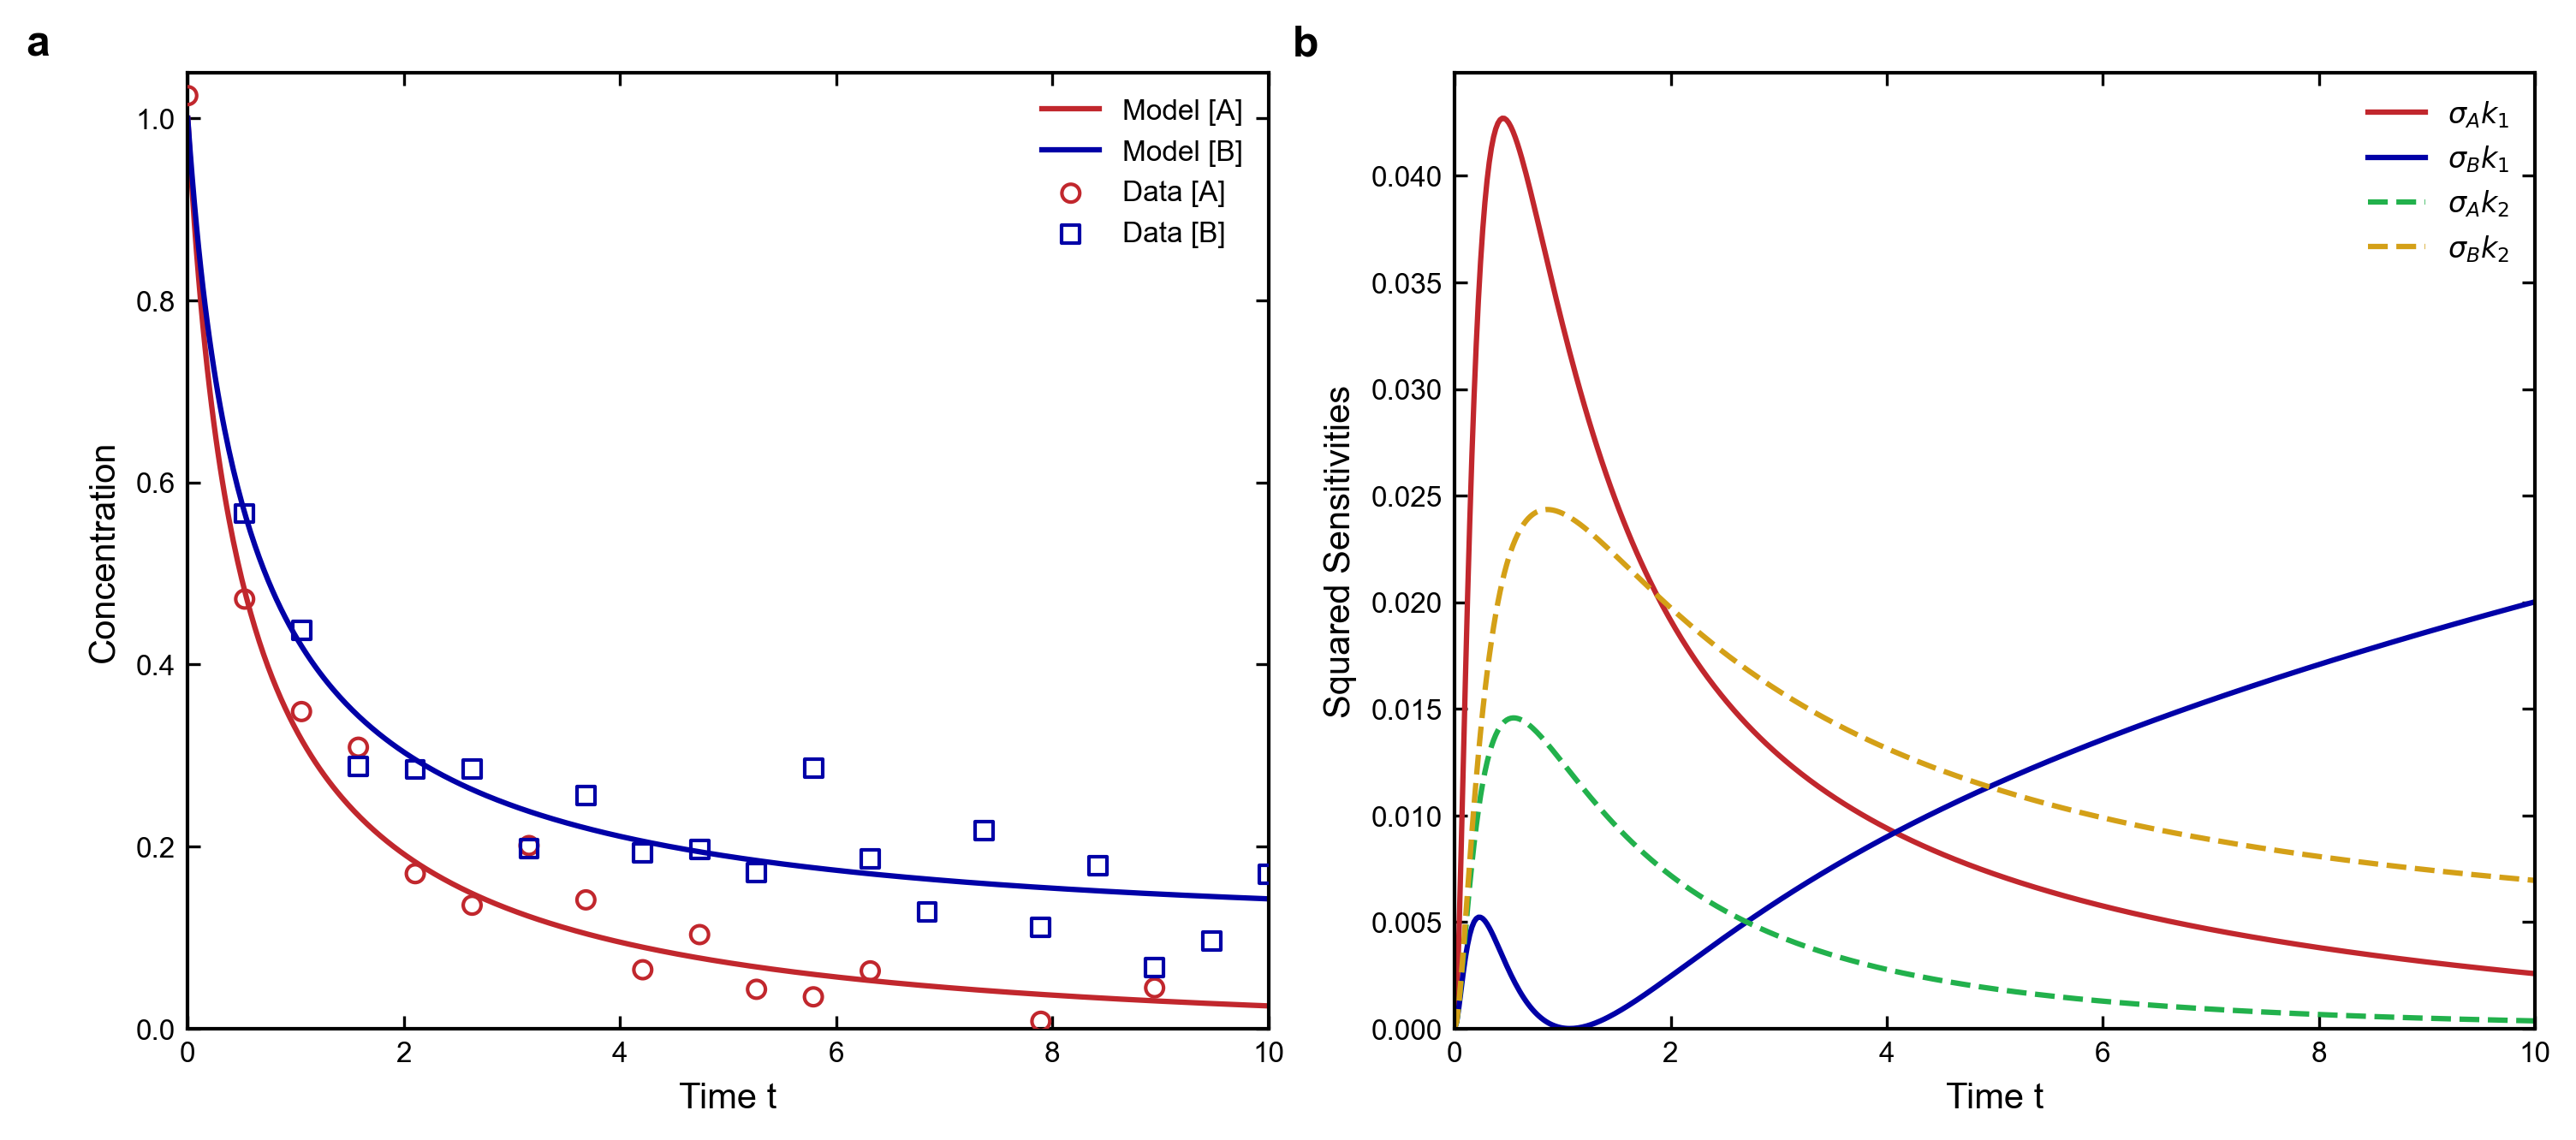

In [7]:
def create_publication_figure(n_cols: int = 2, figsize: Tuple[float, float] = (10, 4.5)) -> Tuple[plt.Figure, np.ndarray, Dict[str, str]]:
    """
    Konfiguriert matplotlib für publikationsreife Abbildungen und initialisiert die Subplots.
    """
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 9,
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'legend.fontsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'axes.linewidth': 1.0,
        'lines.linewidth': 1.5,
        'figure.dpi': 300
    })
    
    colors = {
        'A': '#c1272d',    
        'B': '#0000a7',    
        'sA2': '#22b14c',  
        'sB2': '#d4a017'   
    }
    
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)
    return fig, axes, colors

# Simulation für hochauflösenden Plot
t_plot = np.linspace(0, 10, 500)
y0_ext_plot = np.array([y0_base[0], y0_base[1], 0.0, 0.0, 0.0, 0.0])

sol_plot = solve_ivp(
    fun=lambda t, y: extended_reaction_system(t, y, p_est),
    t_span=(t_plot[0], t_plot[-1]),
    y0=y0_ext_plot,
    t_eval=t_plot,
    method='BDF',
    rtol=1e-10,
    atol=1e-12
)

A_sim, B_sim = sol_plot.y[0], sol_plot.y[1]
sA1_sim, sB1_sim = sol_plot.y[2], sol_plot.y[3]
sA2_sim, sB2_sim = sol_plot.y[4], sol_plot.y[5]

n_t = len(t_eval)
y_noisy_A = y_noisy_flat[:n_t]
y_noisy_B = y_noisy_flat[n_t:]

# Initialisierung von Layout und Farbpalette
fig, axes, cols = create_publication_figure(n_cols=2, figsize=(10, 4.5))

# Subplot 1: Konzentrationen
axes[0].plot(t_plot, A_sim, color=cols['A'], label='Model [A]', zorder=2)
axes[0].plot(t_plot, B_sim, color=cols['B'], label='Model [B]', zorder=2)
axes[0].scatter(t_eval, y_noisy_A, facecolors='none', edgecolors=cols['A'], 
                marker='o', s=25, label='Data [A]', zorder=3)
axes[0].scatter(t_eval, y_noisy_B, facecolors='none', edgecolors=cols['B'], 
                marker='s', s=25, label='Data [B]', zorder=3)

axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Concentration')
axes[0].set_xlim([0, 10])
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc='upper right', frameon=False)
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, 
             fontsize=12, fontweight='bold', va='top')

# Subplot 2: Sensitivitäten
axes[1].plot(t_plot, sA1_sim**2, color=cols['A'], linestyle='-', label=r'$\sigma_{A}k_1$')
axes[1].plot(t_plot, sB1_sim**2, color=cols['B'], linestyle='-', label=r'$\sigma_{B}k_1$')
axes[1].plot(t_plot, sA2_sim**2, color=cols['sA2'], linestyle='--', label=r'$\sigma_{A}k_2$')
axes[1].plot(t_plot, sB2_sim**2, color=cols['sB2'], linestyle='--', label=r'$\sigma_{B}k_2$')

axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Squared Sensitivities')
axes[1].set_xlim([0, 10])
axes[1].set_ylim(bottom=0)
axes[1].legend(loc='upper right', frameon=False)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, 
             fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.show()

### Geometry of Parameter Uncertainty: The Confidence Ellipse

The parameter variance-covariance matrix contains complete information regarding the precision and pairwise correlation of the estimated parameters. Geometrically, this uncertainty can be visualized as a confidence region, which takes the exact form of an n-dimensional ellipsoid for linear models, or a highly accurate linear approximation thereof for moderately non-linear DAE systems.

For two parameters, this bounded region is a 2D confidence ellipse. Its structural properties are derived directly from the eigenvalue decomposition of the covariance matrix:
1. **Orientation:** The eigenvectors indicate the directions of the principal axes in the parameter space. A significant tilt in the ellipse reveals a high cross-correlation between the two parameters.
2. **Axis Lengths:** The lengths of the semi-major and semi-minor axes are proportional to the square roots of the corresponding eigenvalues $\lambda$.
3. **Scaling:** To represent a specific probability level $\alpha$ (typically 95%), the axes are scaled using the critical value derived from the $\chi^2$-distribution with $p=2$ degrees of freedom.

The parametric coordinate equations for the scaled and rotated confidence ellipse are constructed by computing the standard circular coordinates, stretching them by the calculated axes lengths, and rotating the result using a matrix $R$ defined by the angle of the dominant eigenvector.

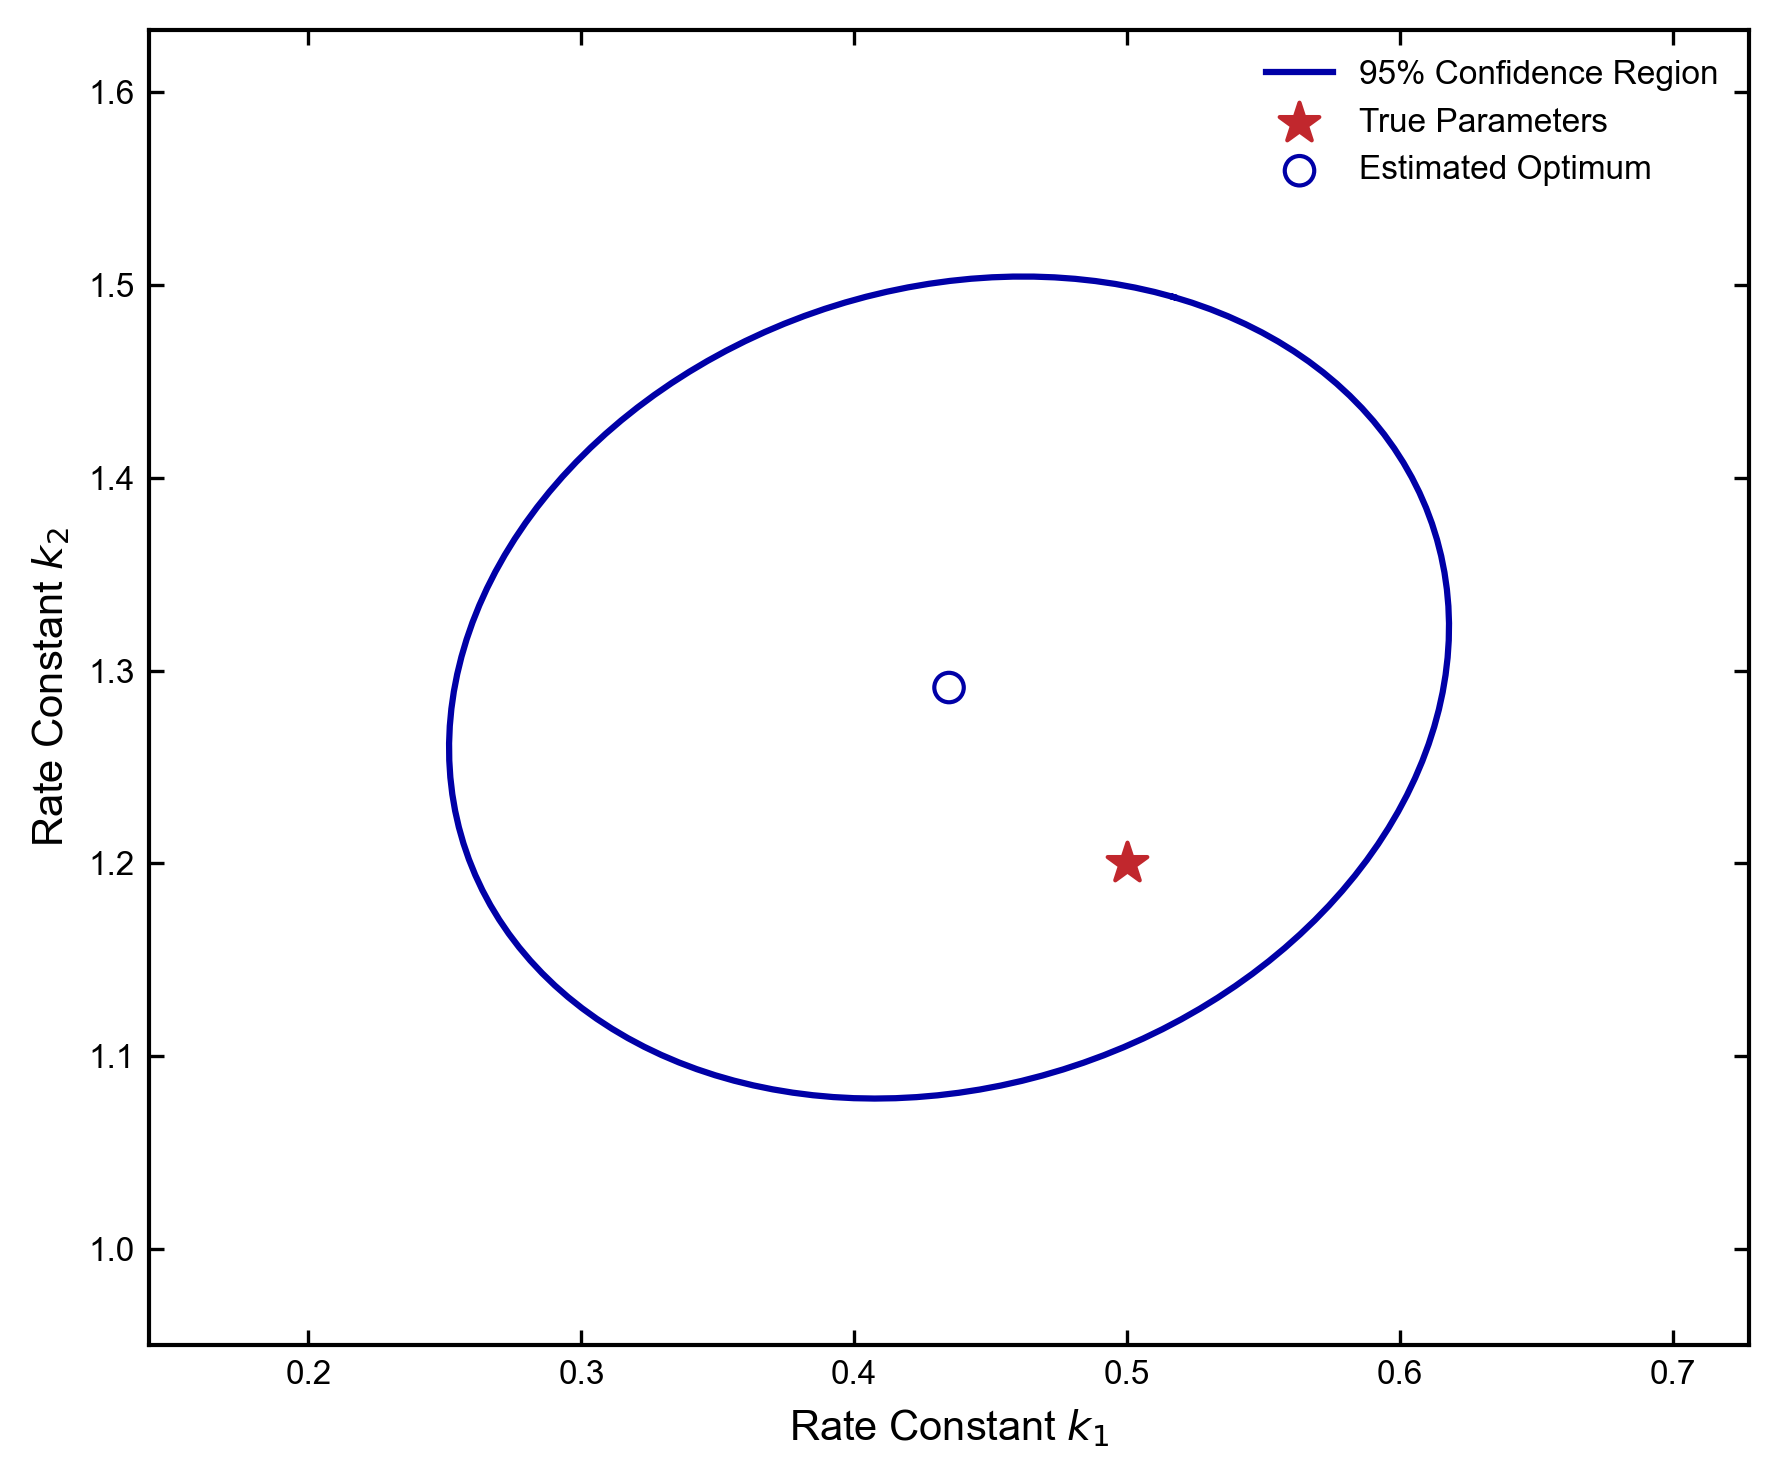

In [8]:
from scipy.stats import chi2

def calculate_confidence_ellipse(p_est: np.ndarray, cov_matrix: np.ndarray, alpha: float = 0.95) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes the 2D spatial coordinates of the confidence ellipse for two estimated parameters.
    
    Parameters:
        p_est: Array containing the estimated parameter values [k1, k2].
        cov_matrix: The 2x2 parameter variance-covariance matrix.
        alpha: The desired confidence level (default: 0.95).
        
    Returns:
        ellipse_x, ellipse_y: Arrays of x and y coordinates defining the ellipse boundary.
    """
    # Eigenvalue decomposition of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues and eigenvectors in descending order to identify major/minor axes
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Extract the critical value from the chi-square distribution for 2 degrees of freedom
    chisquare_val = np.sqrt(chi2.ppf(alpha, 2))
    
    # Calculate the lengths of the semi-major (a) and semi-minor (b) axes
    a = chisquare_val * np.sqrt(np.abs(eigenvalues[0]))
    b = chisquare_val * np.sqrt(np.abs(eigenvalues[1]))
    
    # Calculate the angle of rotation relative to the x-axis
    angle = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    if angle < 0:
        angle += 2 * np.pi
        
    # Generate parametric coordinates for the unrotated, origin-centered ellipse
    theta_grid = np.linspace(0, 2 * np.pi, 150)
    ellipse_x_unrotated = a * np.cos(theta_grid)
    ellipse_y_unrotated = b * np.sin(theta_grid)
    
    # Construct the 2D rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    
    # Apply rotation and translate the origin to the estimated parameter values
    ellipse_coords = np.column_stack((ellipse_x_unrotated, ellipse_y_unrotated)) @ R.T
    ellipse_x = ellipse_coords[:, 0] + p_est[0]
    ellipse_y = ellipse_coords[:, 1] + p_est[1]
    
    return ellipse_x, ellipse_y

# =============================================================================
# Execution and Visualization (Pre-DoE)
# =============================================================================

# Calculate the ellipse coordinates using the previously determined covariance matrix
ell_x, ell_y = calculate_confidence_ellipse(p_est, cov_matrix, alpha=0.95)

# Initialize the publication-ready plot
fig, ax, cols = create_publication_figure(n_cols=1, figsize=(6, 5))
ax = np.atleast_1d(ax)[0] 

# Plot the calculated confidence ellipse
ax.plot(ell_x, ell_y, color=cols['B'], linestyle='-', label='95% Confidence Region')

# Highlight the true parameter set and the estimated parameter set
ax.scatter(p_true[0], p_true[1], color=cols['A'], marker='*', s=100, label='True Parameters', zorder=4)
ax.scatter(p_est[0], p_est[1], facecolors='none', edgecolors=cols['B'], marker='o', s=50, label='Estimated Optimum', zorder=4)

# Format the plot
ax.set_xlabel('Rate Constant $k_1$')
ax.set_ylabel('Rate Constant $k_2$')
ax.legend(loc='best', frameon=False)
ax.tick_params(direction='in', top=True, right=True)

# Determine symmetrical dynamic limits to ensure the ellipse is fully visible
x_margin = (np.max(ell_x) - np.min(ell_x)) * 0.3
y_margin = (np.max(ell_y) - np.min(ell_y)) * 0.3
ax.set_xlim([np.min(ell_x) - x_margin, np.max(ell_x) + x_margin])
ax.set_ylim([np.min(ell_y) - y_margin, np.max(ell_y) + y_margin])

plt.tight_layout()
plt.show()

### Monte Carlo Analysis for Empirical Uncertainty Quantification

The linear approximation based on the Fisher Information Matrix (derived via the Jacobian) provides a highly computationally efficient estimate of parameter uncertainty. However, it relies on the fundamental assumption that the model behaves linearly in the immediate vicinity of the optimal parameter set. For highly nonlinear dynamic models, this assumption can fail, leading to asymmetric or distorted confidence regions that a strict ellipse cannot capture.

A rigorous, computationally expensive, alternative is the Monte Carlo method. This approach empirically reconstructs the probability distribution of the parameter estimates. The procedure involves repeating the data generation and parameter estimation cycle numerous times:
1. Generate a synthetic dataset by adding newly sampled normally distributed noise to the true model trajectories.
2. Execute the optimization algorithm to find the parameter estimates for this specific synthetic dataset.
3. Store the estimated parameter pairs.

By scattering these Monte Carlo estimates in the parameter space and overlaying the previously calculated linear confidence ellipse, we achieve a direct visual validation. If the linear approximation holds, approximately 95% of the scattered empirical estimates will fall within the calculated confidence boundary. Any distinct curvature or "banana shape" in the scatter plot serves as a clear indicator of structural non-linearity.

Starting Monte Carlo analysis with 100 iterations...

Status: Iteration 100/100 successfully evaluated.

Monte Carlo analysis completed.


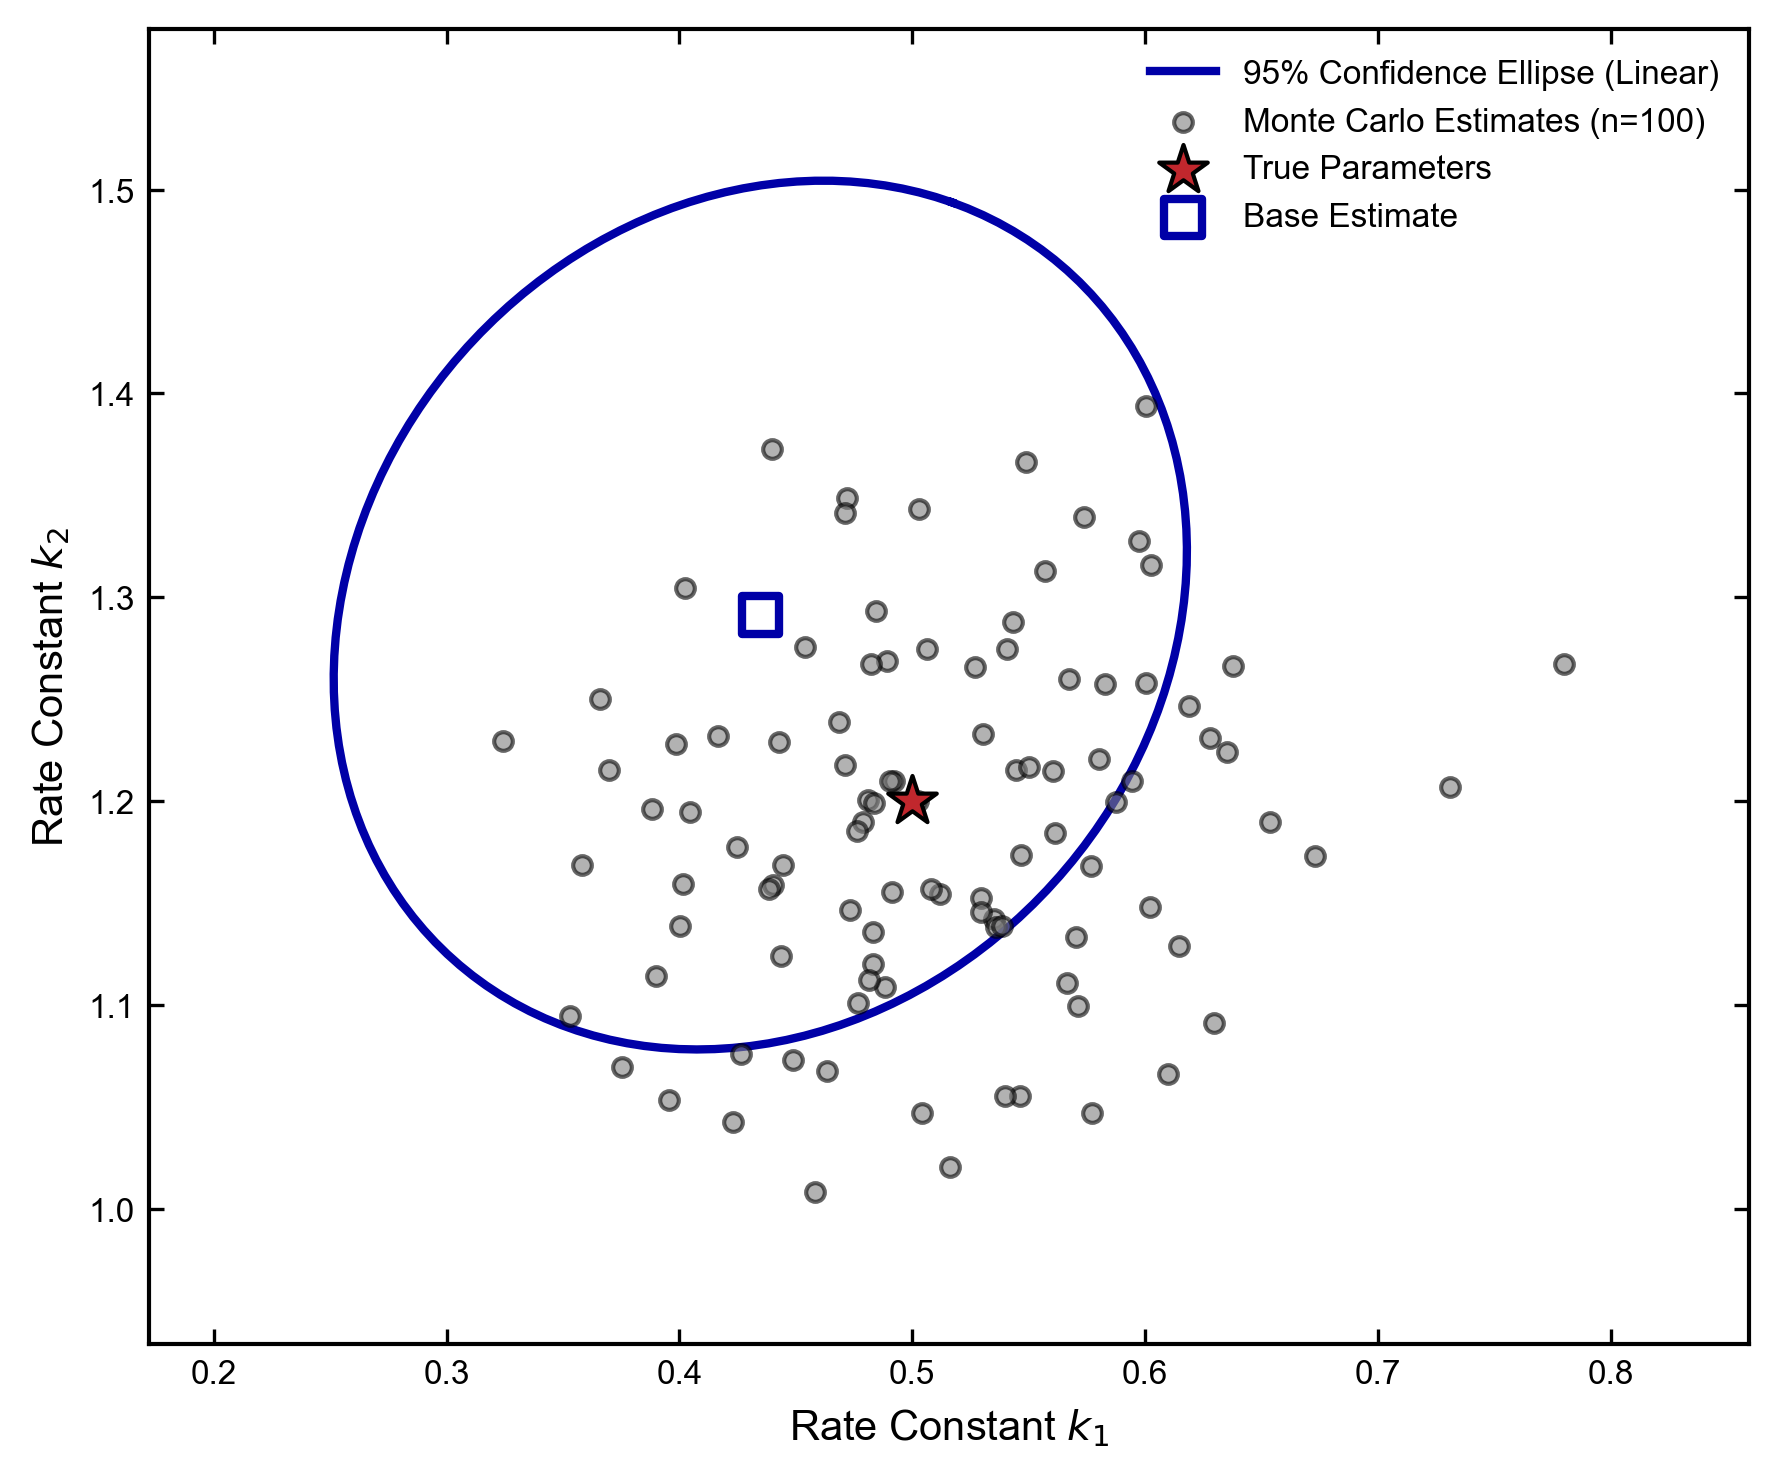

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# =============================================================================
# Monte Carlo Parameter Estimation
# =============================================================================

n_iterations = 100
p_mc_estimates = np.zeros((n_iterations, 2))

# Use a different seed to ensure new noise generation
np.random.seed(101)

print(f"Starting Monte Carlo analysis with {n_iterations} iterations...\n")

for i in range(n_iterations):
    # Generate new synthetic measurement data with the established noise level
    y_noisy_mc = y_true_flat + np.random.normal(0, noise_level, y_true_flat.shape)
    
    # Perform parameter estimation for the current noisy dataset
    res_mc = least_squares(
        fun=residuals_fun,
        x0=p_guess,
        jac=jacobian_fun,
        args=(t_eval, y_noisy_mc, y0_base),
        method='lm'
    )
    
    p_mc_estimates[i, :] = res_mc.x
    
    # Dynamic progress tracking overwriting the current line
    print(f"Status: Iteration {i + 1}/{n_iterations} successfully evaluated.", end='\r')

print("\n\nMonte Carlo analysis completed.")

# =============================================================================
# Visualization: Monte Carlo Scatter vs. Linear Confidence Ellipse
# =============================================================================

# Initialize the publication-ready plot
fig, ax, cols = create_publication_figure(n_cols=1, figsize=(6, 5))
ax = np.atleast_1d(ax)[0] 

# 1. Plot the analytical 95% confidence ellipse (from the previous cell)
ax.plot(ell_x, ell_y, color=cols['B'], linestyle='-', linewidth=2, label='95% Confidence Ellipse (Linear)')

# 2. Scatter the empirical Monte Carlo estimates
ax.scatter(p_mc_estimates[:, 0], p_mc_estimates[:, 1], 
           color='gray', alpha=0.6, edgecolors='black', marker='o', s=20, 
           label=f'Monte Carlo Estimates (n={n_iterations})', zorder=2)

# 3. Highlight the true parameter set and the single initial estimate
ax.scatter(p_true[0], p_true[1], color=cols['A'], marker='*', s=150, 
           edgecolors='black', label='True Parameters', zorder=4)
ax.scatter(p_est[0], p_est[1], facecolors='none', edgecolors=cols['B'], 
           marker='s', s=80, linewidth=2, label='Base Estimate', zorder=4)

# Format the plot
ax.set_xlabel('Rate Constant $k_1$')
ax.set_ylabel('Rate Constant $k_2$')
ax.legend(loc='best', frameon=False)
ax.tick_params(direction='in', top=True, right=True)

# Adjust dynamic limits to capture both the ellipse and potential outlier scatter points
all_x = np.concatenate((ell_x, p_mc_estimates[:, 0]))
all_y = np.concatenate((ell_y, p_mc_estimates[:, 1]))

x_margin = (np.max(all_x) - np.min(all_x)) * 0.15
y_margin = (np.max(all_y) - np.min(all_y)) * 0.15

ax.set_xlim([np.min(all_x) - x_margin, np.max(all_x) + x_margin])
ax.set_ylim([np.min(all_y) - y_margin, np.max(all_y) + y_margin])

plt.tight_layout()
plt.show()

# Model-Based Optimal Experimental Design (OED)
The core metric for quantifying expected information is the Fisher Information Matrix (FIM). For a set of $N_{raw}$ potential measurement times, the total FIM is constructed as a weighted sum of local information matrices. If $Q$ defines the sensitivity matrix of the responses with respect to the parameters, and $W$ is a diagonal weighting matrix, the FIM is formulated as:

$$
FIM = Q^T W Q = \sum_{i=1}^{N_{raw}} w_i J_i^T J_i
$$

Here, $J_i$ is the local Jacobian of the measured states (A and B) evaluated at time $t_i$, and $w_i \in [0, 1]$ represents the continuous experimental effort allocated to that specific sampling time. Selecting exactly $n$ sampling times is computationally demanding due to its combinatorial nature. By relaxing the integer constraints and treating $w_i$ as continuous variables bounded by $0 \le w_i \le 1$ with the equality constraint $\sum w_i = n$, the problem is transformed into a continuous Nonlinear Program (NLP).

The optimization objective reduces the uncertainty volume. Two standard scalar metrics are defined:
1. **D-Optimal Design:** Maximizes the determinant of the FIM, which minimizes the overall volume of the joint confidence ellipsoid. 
   $$\text{Criterion } D = \max (\det(FIM)) \equiv \min (-\log(\det(FIM)))$$
2. **E-Optimal Design:** Maximizes the smallest eigenvalue of the FIM, minimizing the length of the largest principal axis of the confidence ellipsoid.
   $$\text{Criterion } E = \max (\lambda_{min}(FIM)) \equiv \min (-\lambda_{min}(FIM))$$

Simultaneously, the initial substrate concentrations $y_0 = [A_0, B_0]$ are included as design variables to locate the optimal starting conditions for the subsequent experiment.

Starting D-Optimal Design optimization with CSD...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3.413416116781485
            Iterations: 46
            Function evaluations: 1978
            Gradient evaluations: 46


--- Optimal Experimental Design Results ---
Optimized Initial Concentrations: [A0] = 5.0000, [B0] = 4.0163
Selected 20 Measurement Times extracted from continuous weights.


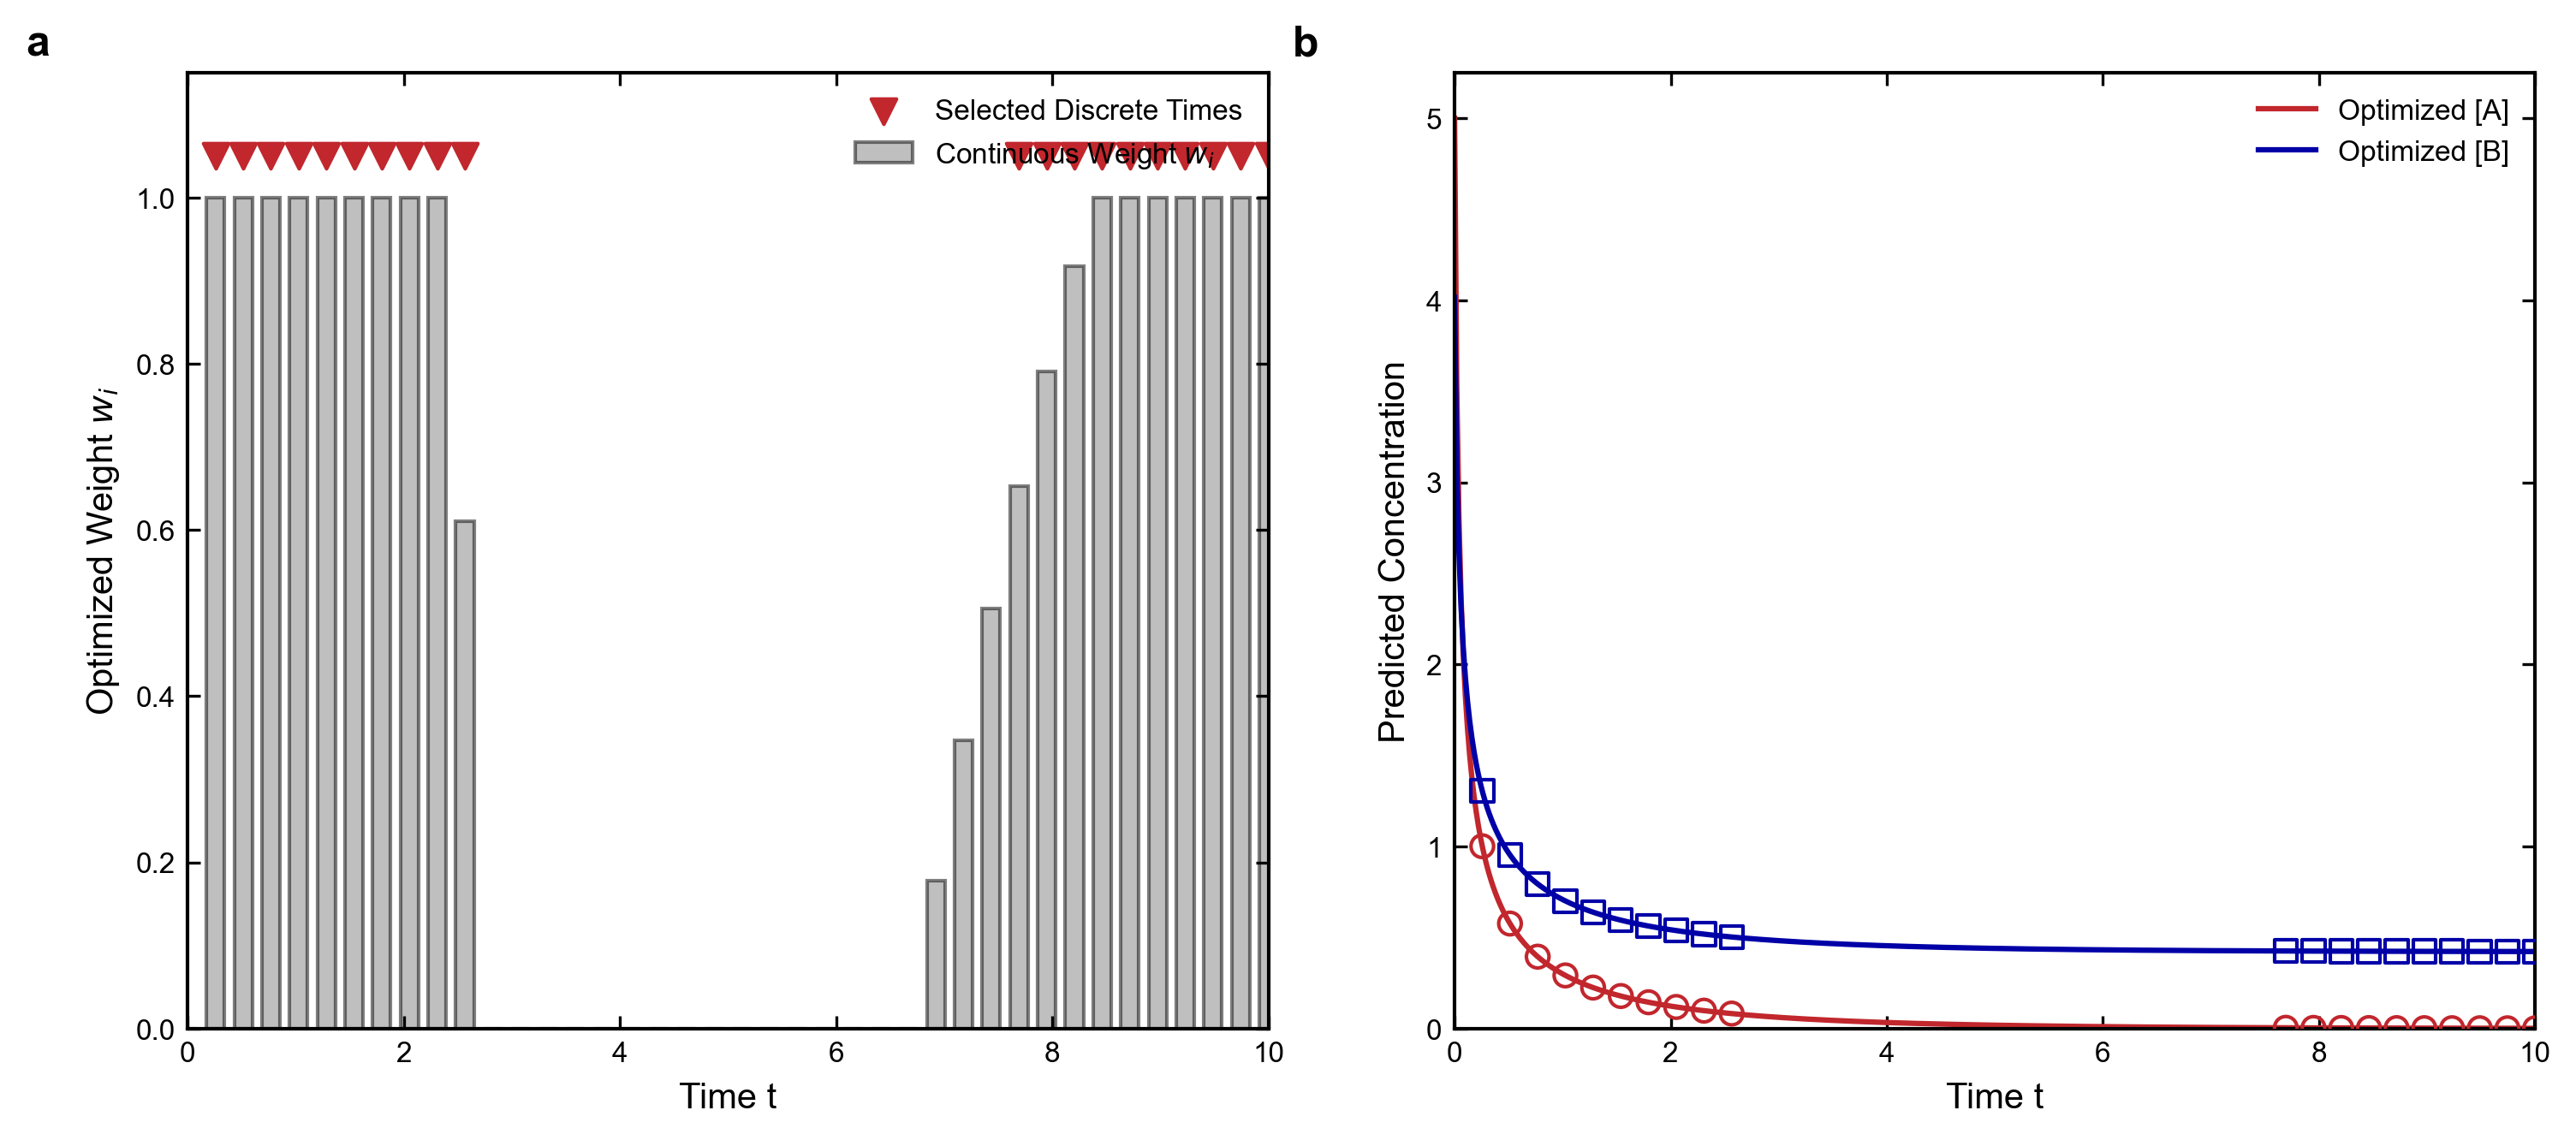

In [13]:
from scipy.optimize import minimize
# =============================================================================
# 1. Definition of the OED Framework using Complex Step Differentiation
# =============================================================================

t_eval_raw = np.linspace(0, 10, 40)
n_measurements = 20

# The OED must be evaluated at the best known parameter set (nominal parameters)
p_nom = p_est 

def evaluate_fim_csd(x: np.ndarray, p: np.ndarray, t_raw: np.ndarray) -> np.ndarray:
    """
    Evaluates the Fisher Information Matrix using the Complex Step Jacobian.
    """
    conc_initial = x[:2]
    w = x[2:]
    
    # Calculate the full Jacobian using the highly accurate CSD method
    # J_flat has the shape (2 * len(t_raw), n_params)
    J_flat = jacobian_csd(p, t_raw, conc_initial)
    
    # Since J_flat contains the stacked responses for A and B, 
    # the temporal weights must be duplicated to match the shape.
    w_full = np.concatenate((w, w))
    
    # Efficient vectorized calculation of FIM = J^T * W * J
    FIM = (J_flat.T * w_full) @ J_flat
    
    return FIM

def objective_oed(x: np.ndarray, p: np.ndarray, t_raw: np.ndarray, criterion: str = 'D') -> float:
    """Objective function for the SLSQP optimizer."""
    FIM = evaluate_fim_csd(x, p, t_raw)
    
    # Add numerical regularization to prevent singular matrix errors during search
    FIM += np.eye(2) * 1e-12 
    
    if criterion == 'D':
        det_fim = np.linalg.det(FIM)
        # Prevent math domain error for non-positive determinants
        if det_fim <= 0:
            return 1e9 
        return -np.log(det_fim)
    elif criterion == 'E':
        eigenvalues = np.linalg.eigvalsh(FIM)
        return -np.min(eigenvalues)
    else:
        raise ValueError("Criterion must be 'D' or 'E'")

# =============================================================================
# 2. Execution of the Optimization
# =============================================================================

# Choose the design criterion ('D' or 'E')
design_crit = 'D'

# Initialize guess for the design variables
conc_initial_guess = np.array([1.0, 1.0])
w_guess = np.ones(len(t_eval_raw)) * (n_measurements / len(t_eval_raw))
x0_oed = np.concatenate((conc_initial_guess, w_guess))

# Define bounds: concentrations in [0.1, 5.0], weights in [0, 1]
bounds_conc = [(0.1, 5.0), (0.1, 5.0)]
bounds_w = [(0.0, 1.0)] * len(t_eval_raw)
bounds = bounds_conc + bounds_w

# Define constraint: Sum of weights must equal the number of available measurements
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x[2:]) - n_measurements}]

# Callback function to track SLSQP iterations dynamically
iteration_count = 0
def oed_callback(x: np.ndarray):
    global iteration_count
    iteration_count += 1
    print(f"Status: SLSQP Iteration {iteration_count} completed.", end='\r')

print(f"Starting {design_crit}-Optimal Design optimization with CSD...")

res_oed = minimize(
    fun=objective_oed,
    x0=x0_oed,
    args=(p_nom, t_eval_raw, design_crit),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    callback=oed_callback,
    options={'maxiter': 200, 'ftol': 1e-5, 'disp': True}
)

conc_initial_opt = res_oed.x[:2]
w_opt = res_oed.x[2:]

# Extract the exact discrete sampling points by selecting the highest weights
top_indices = np.argsort(w_opt)[-n_measurements:]
top_indices = np.sort(top_indices)
t_eval_opt = t_eval_raw[top_indices]

print("\n\n--- Optimal Experimental Design Results ---")
print(f"Optimized Initial Concentrations: [A0] = {conc_initial_opt[0]:.4f}, [B0] = {conc_initial_opt[1]:.4f}")
print(f"Selected {n_measurements} Measurement Times extracted from continuous weights.")

# =============================================================================
# 3. Visualization of the Design
# =============================================================================

fig, axes, cols = create_publication_figure(n_cols=2, figsize=(10, 4.5))

# Panel (a): Continuous Weights Distribution
axes[0].bar(t_eval_raw, w_opt, width=10/60, color='gray', alpha=0.5, edgecolor='black', label='Continuous Weight $w_i$')
axes[0].scatter(t_eval_opt, np.ones(n_measurements)*1.05, marker='v', color=cols['A'], s=50, label='Selected Discrete Times')

axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Optimized Weight $w_i$')
axes[0].set_xlim([0, 10])
axes[0].set_ylim([0, 1.15])
axes[0].legend(loc='upper right', frameon=False)
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')

# Panel (b): Predicted Optimal Trajectories
y0_opt_plot = np.array([conc_initial_opt[0], conc_initial_opt[1]])
# Calculate the optimal trajectories using the base model
sol_opt_flat = simulate_base_model(p_nom, t_plot, y0_opt_plot)
A_opt_sim = sol_opt_flat[:len(t_plot)]
B_opt_sim = sol_opt_flat[len(t_plot):]

axes[1].plot(t_plot, A_opt_sim, color=cols['A'], label='Optimized [A]')
axes[1].plot(t_plot, B_opt_sim, color=cols['B'], label='Optimized [B]')

# Overlay the selected discrete sampling points on the curves
A_points = np.interp(t_eval_opt, t_plot, A_opt_sim)
B_points = np.interp(t_eval_opt, t_plot, B_opt_sim)

axes[1].scatter(t_eval_opt, A_points, facecolors='none', edgecolors=cols['A'], marker='o', s=40, zorder=3)
axes[1].scatter(t_eval_opt, B_points, facecolors='none', edgecolors=cols['B'], marker='s', s=40, zorder=3)

axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Predicted Concentration')
axes[1].set_xlim([0, 10])
axes[1].set_ylim(bottom=0)
axes[1].legend(loc='upper right', frameon=False)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# 1. Execution of the Optimized "Virtual Experiment"
# =============================================================================

# Simulate the "true" response at optimized initial conditions and time points
y_true_oed_flat = simulate_base_model(p_true, t_eval_opt, conc_initial_opt)

# Generate new experimental data with the same noise level
np.random.seed(202) # New seed for independent experimental noise
y_noisy_oed_flat = y_true_oed_flat + np.random.normal(0, noise_level, y_true_oed_flat.shape)

# Perform Parameter Estimation using the optimized design
res_oed_final = least_squares(
    fun=residuals_fun,
    x0=p_guess,
    jac=jacobian_fun,
    args=(t_eval_opt, y_noisy_oed_flat, conc_initial_opt),
    method='lm'
)

p_est_oed = res_oed_final.x

# =============================================================================
# 2. Statistical Analysis of the Optimized Result
# =============================================================================

dof_oed = max(0, len(y_noisy_oed_flat) - len(p_est_oed))
mse_oed = np.sum(res_oed_final.fun**2) / dof_oed

J_opt_oed = res_oed_final.jac 
cov_matrix_oed = mse_oed * np.linalg.inv(J_opt_oed.T @ J_opt_oed)

# Calculate coordinates for the new (optimized) confidence ellipse
ell_x_oed, ell_y_oed = calculate_confidence_ellipse(p_est_oed, cov_matrix_oed, alpha=0.95)

# Standard error and confidence interval calculation for Post-OED results
standard_errors_oed = np.sqrt(np.diagonal(cov_matrix_oed))
t_val_oed = t.ppf(1.0 - 0.05 / 2.0, dof_oed)
ci_half_width_oed = t_val_oed * standard_errors_oed

print("--- Post-OED Parameter Estimation Results ---")
print(f"k1: True = {p_true[0]:.4f} | Est = {p_est_oed[0]:.4f} +/- {ci_half_width_oed[0]:.4f}")
print(f"k2: True = {p_true[1]:.4f} | Est = {p_est_oed[1]:.4f} +/- {ci_half_width_oed[1]:.4f}")

--- Post-OED Parameter Estimation Results ---
k1: True = 0.5000 | Est = 0.5269 +/- 0.0379
k2: True = 1.2000 | Est = 1.2495 +/- 0.0776


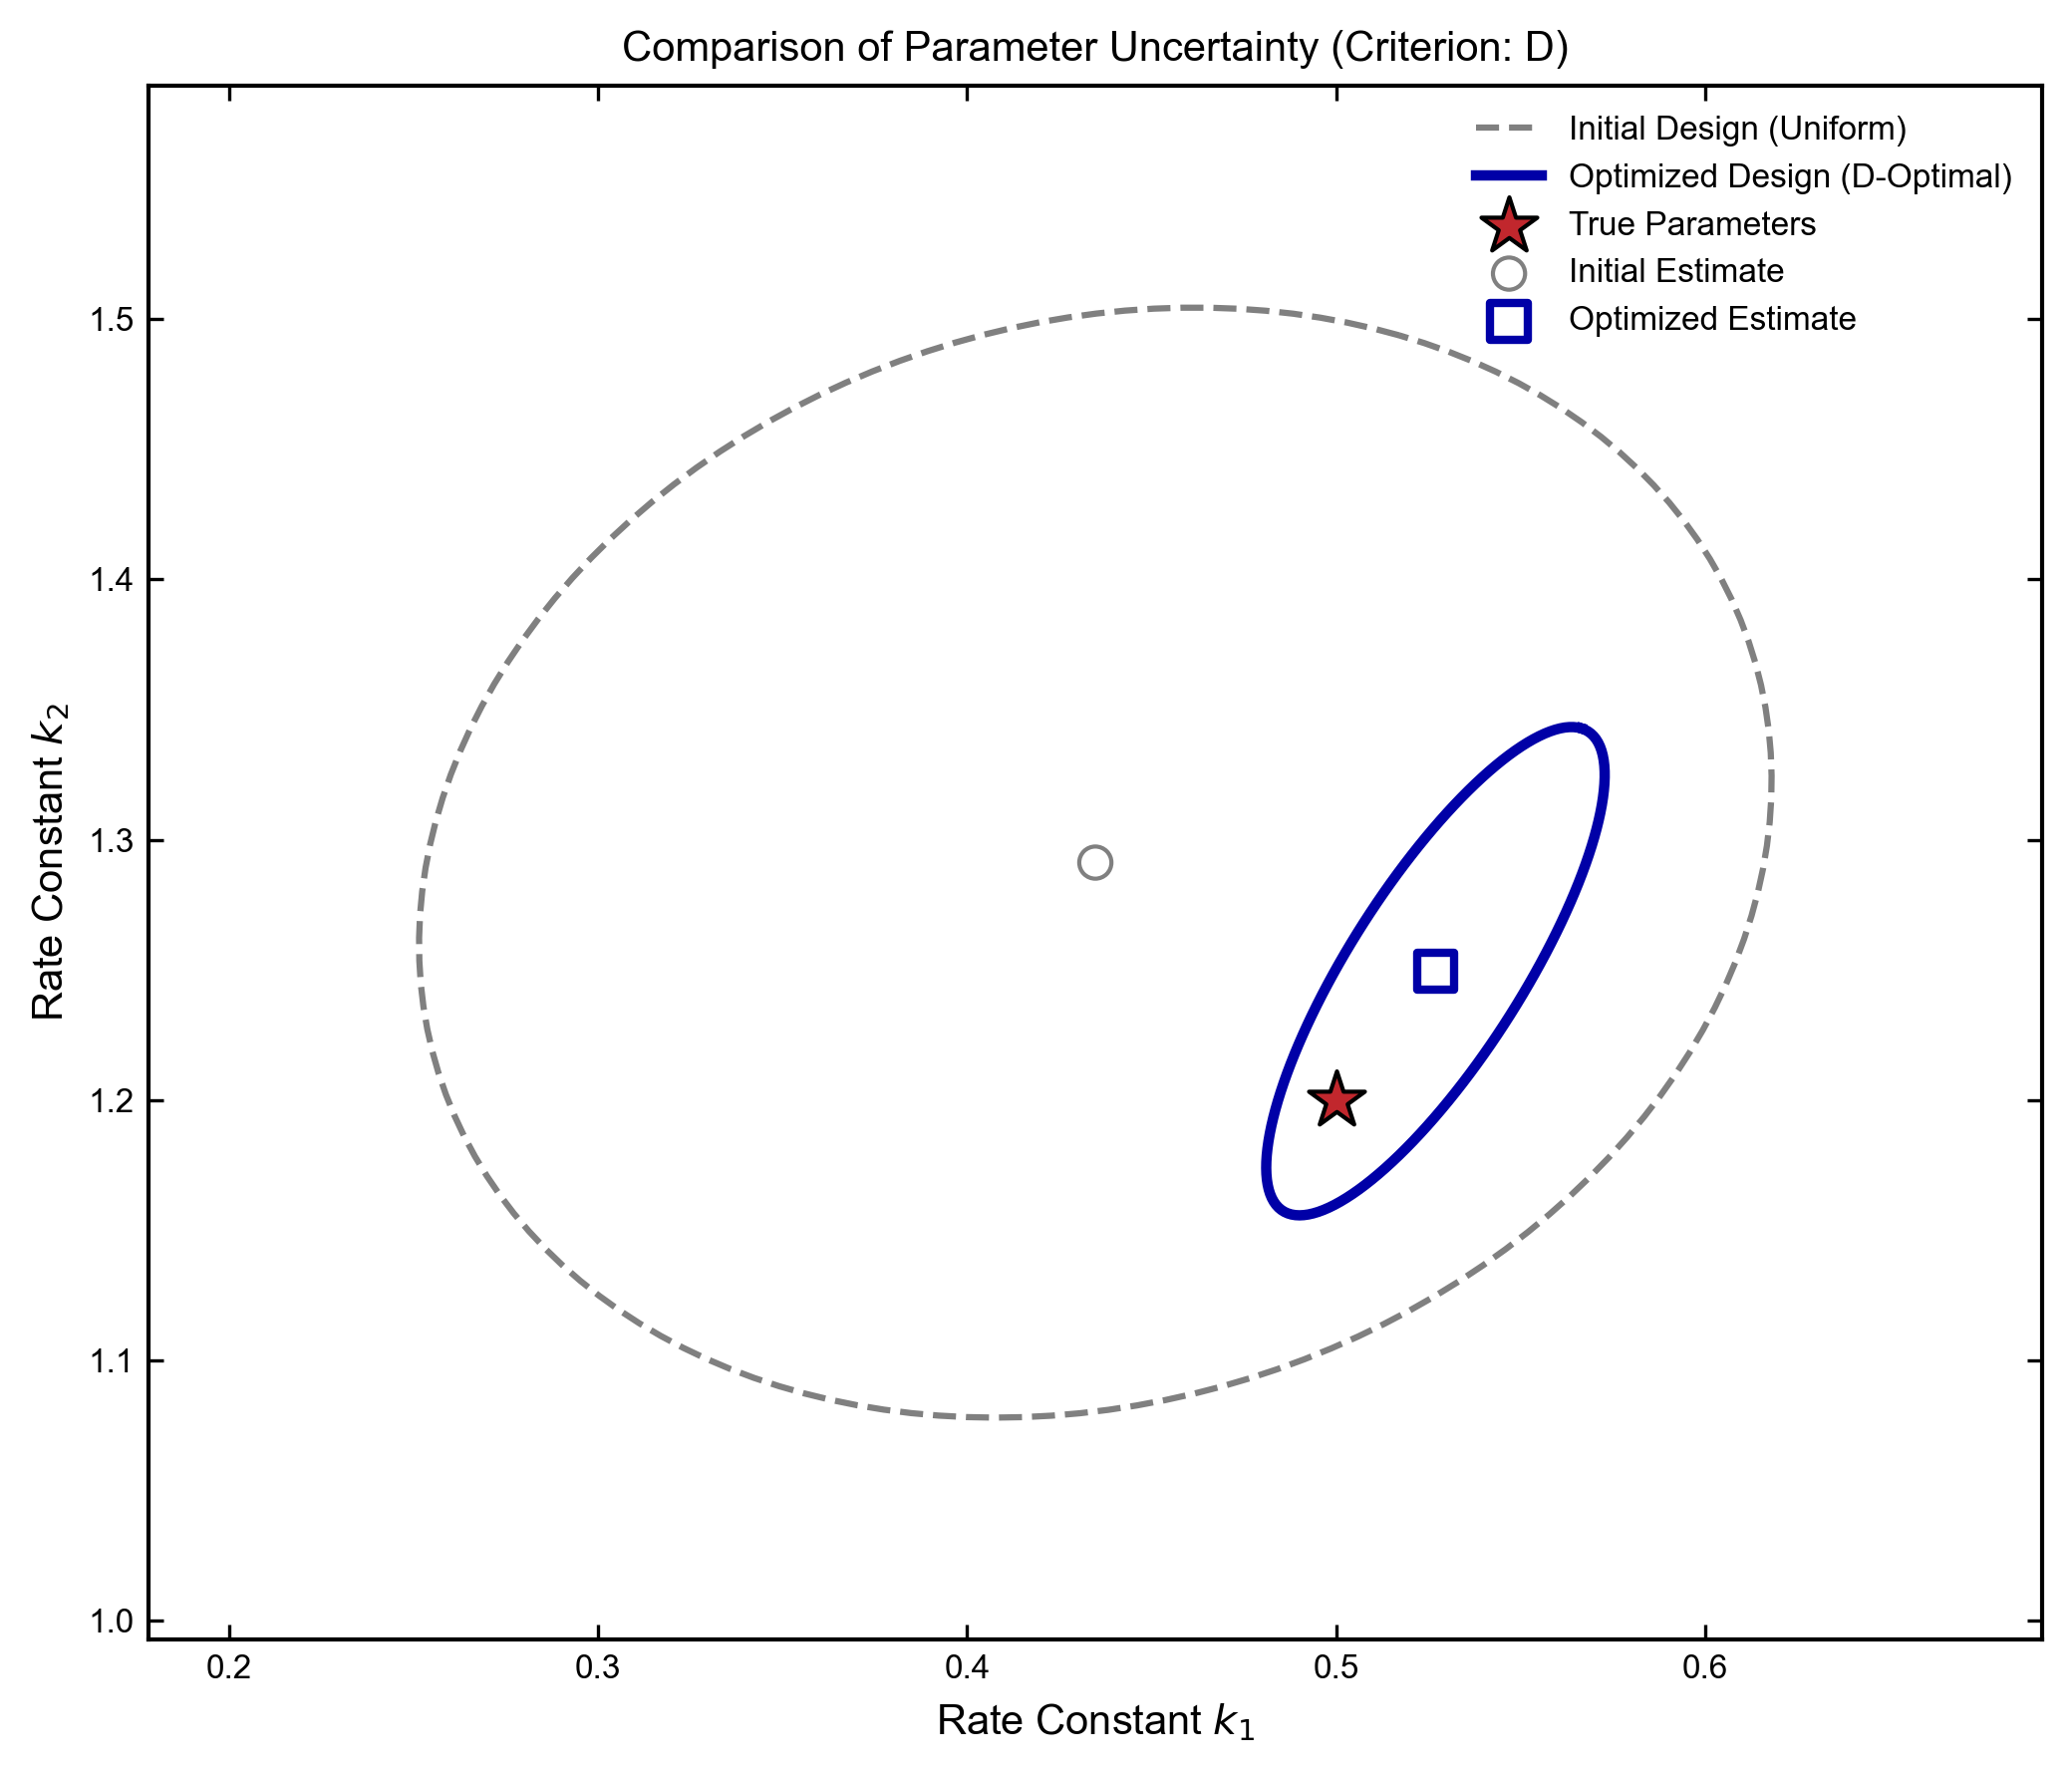

In [15]:
# Initialize the publication-ready plot
fig, ax, cols = create_publication_figure(n_cols=1, figsize=(7, 6))
ax = np.atleast_1d(ax)[0] 

# 1. Plot the Initial (Non-Optimized) Confidence Ellipse
ax.plot(ell_x, ell_y, color='gray', linestyle='--', linewidth=1.5, label='Initial Design (Uniform)')

# 2. Plot the Optimized (Post-OED) Confidence Ellipse
ax.plot(ell_x_oed, ell_y_oed, color=cols['B'], linestyle='-', linewidth=2.5, label='Optimized Design (D-Optimal)')

# 3. Highlight the true parameter set and the estimates
ax.scatter(p_true[0], p_true[1], color=cols['A'], marker='*', s=200, 
           edgecolors='black', label='True Parameters', zorder=5)
ax.scatter(p_est[0], p_est[1], facecolors='none', edgecolors='gray', 
           marker='o', s=60, label='Initial Estimate', zorder=4)
ax.scatter(p_est_oed[0], p_est_oed[1], facecolors='none', edgecolors=cols['B'], 
           marker='s', s=80, linewidth=2, label='Optimized Estimate', zorder=4)

# Format the axes
ax.set_xlabel('Rate Constant $k_1$')
ax.set_ylabel('Rate Constant $k_2$')
ax.set_title(f'Comparison of Parameter Uncertainty (Criterion: {design_crit})')
ax.legend(loc='best', frameon=False)
ax.tick_params(direction='in', top=True, right=True)

# Adjust dynamic limits to capture both ellipses comfortably
all_x_comp = np.concatenate((ell_x, ell_x_oed))
all_y_comp = np.concatenate((ell_y, ell_y_oed))

x_span = np.max(all_x_comp) - np.min(all_x_comp)
y_span = np.max(all_y_comp) - np.min(all_y_comp)

ax.set_xlim([np.min(all_x_comp) - 0.2*x_span, np.max(all_x_comp) + 0.2*x_span])
ax.set_ylim([np.min(all_y_comp) - 0.2*y_span, np.max(all_y_comp) + 0.2*y_span])

plt.tight_layout()
plt.show()

### Sensitivity Evaluation of the Experimental Design

The success of the Optimal Experimental Design (OED) can be visually verified by examining the dynamic sensitivities. The objective of the D-optimal design is to maximize the determinant of the Fisher Information Matrix. Geometrically and algebraically, this translates to placing the discrete measurement points at the exact time intervals where the squared sensitivities of the measured states with respect to the parameters reach their local maxima.

By comparing the initial uniform sampling grid with the optimized sampling grid, it becomes evident that the optimization algorithm successfully shifts the experimental effort (the sampling times) to the regions of highest information content, while simultaneously modifying the initial concentrations to increase the absolute magnitude of these sensitivity peaks.

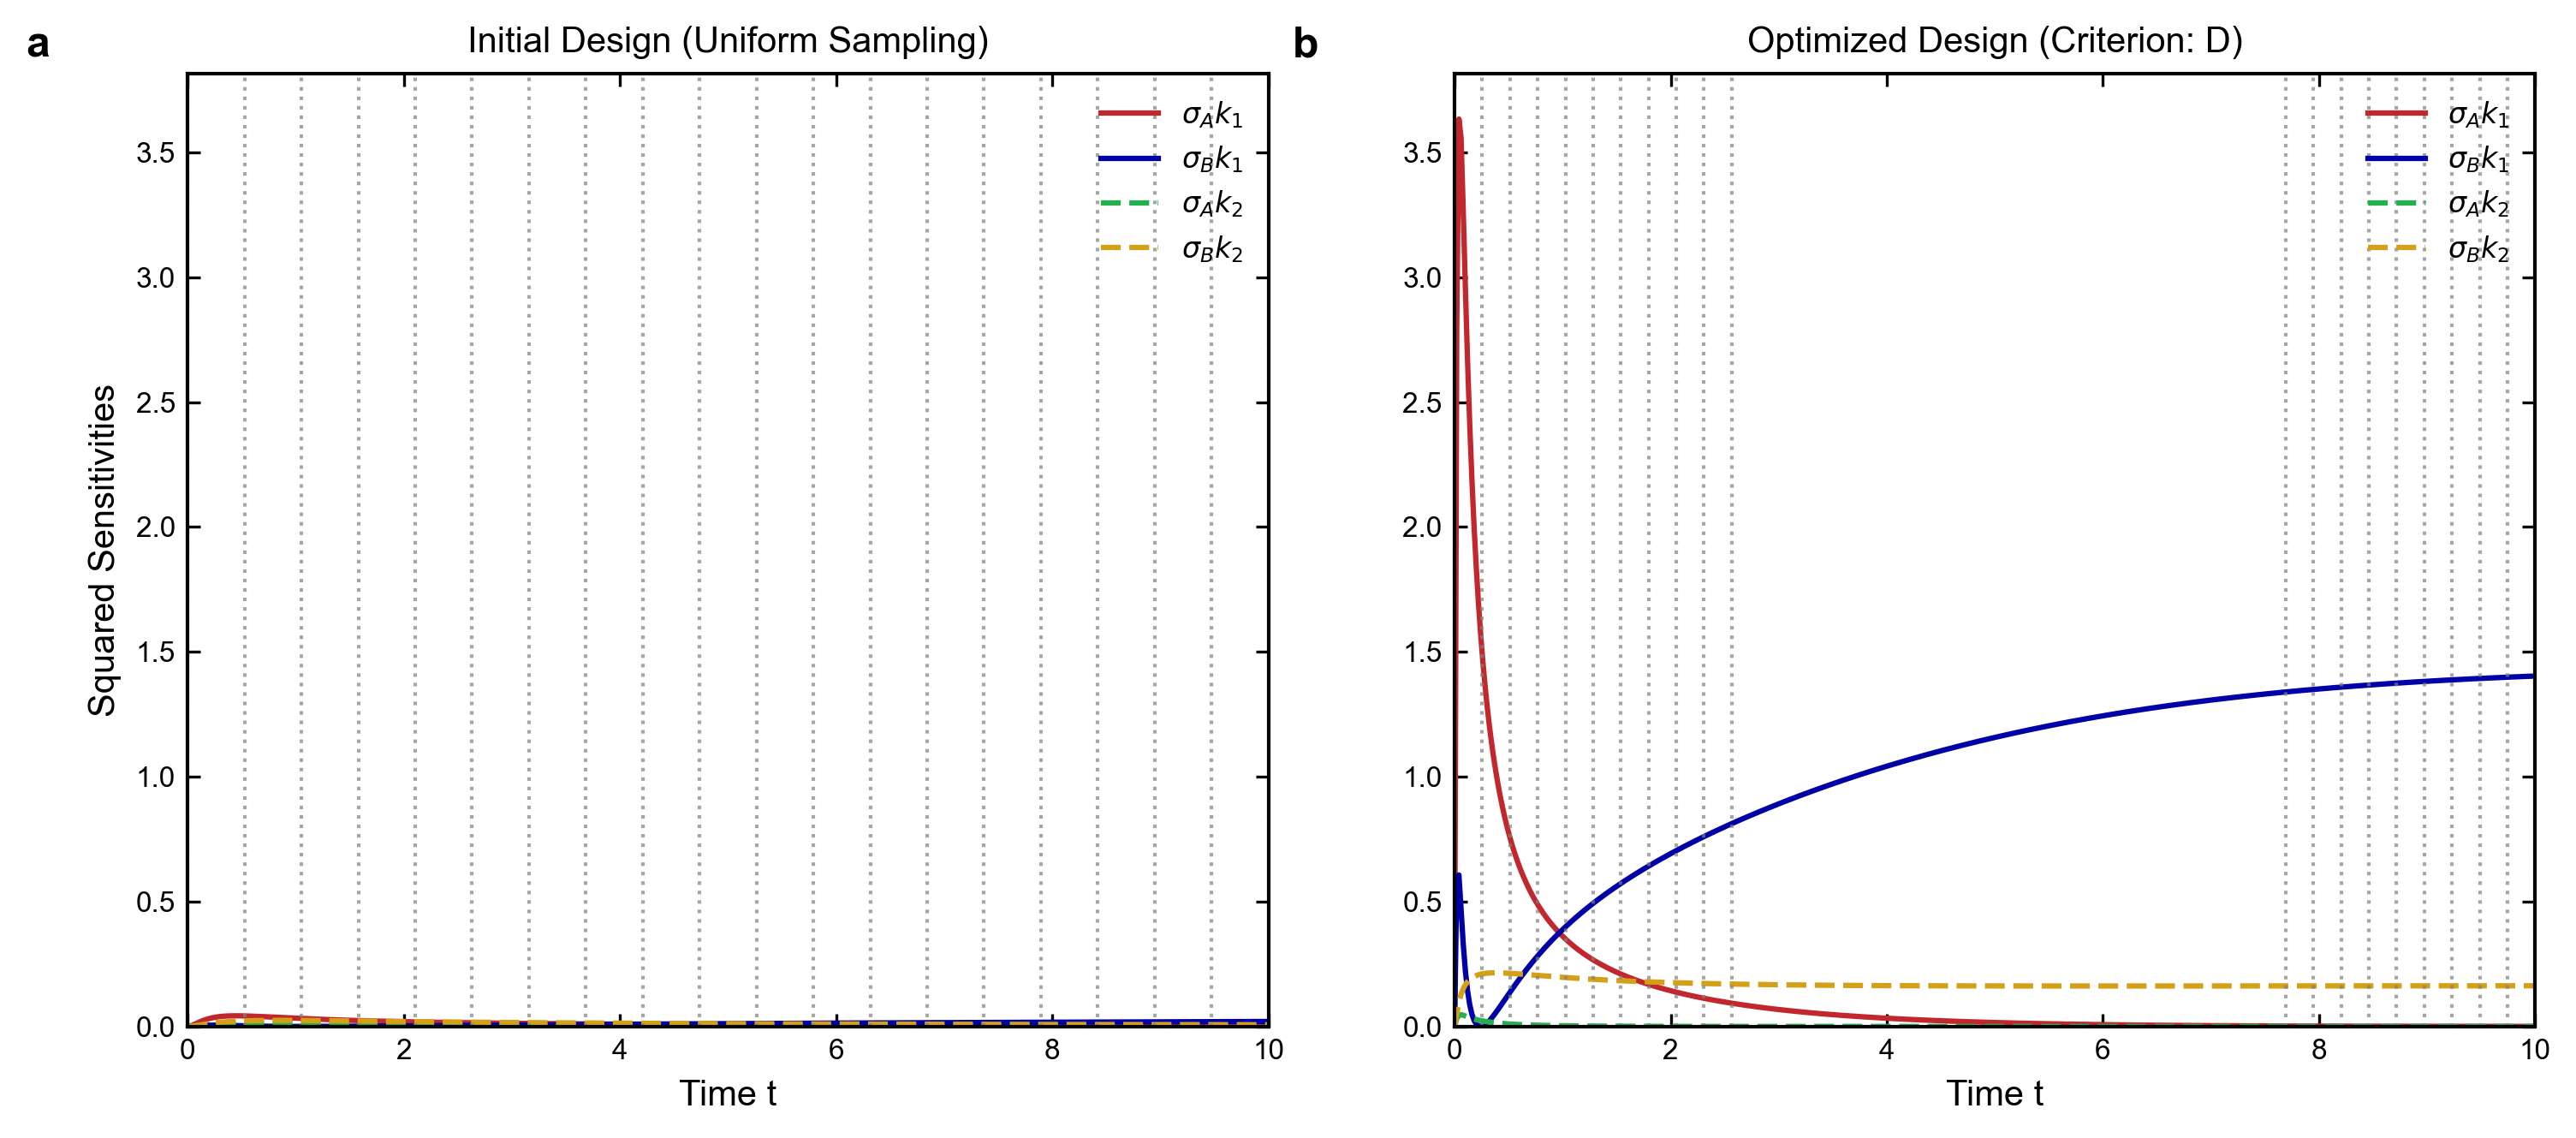

In [17]:
# =============================================================================
# 1. Calculation of Sensitivities for Initial and Optimized Designs
# =============================================================================

# Simulate the extended system for the initial design (y0_base)
y0_ext_base = np.array([y0_base[0], y0_base[1], 0.0, 0.0, 0.0, 0.0])
sol_base_sens = solve_ivp(
    fun=lambda t, y: extended_reaction_system(t, y, p_nom),
    t_span=(t_plot[0], t_plot[-1]),
    y0=y0_ext_base,
    t_eval=t_plot,
    method='BDF',
    rtol=1e-10,
    atol=1e-12
)

sA1_base, sB1_base = sol_base_sens.y[2], sol_base_sens.y[3]
sA2_base, sB2_base = sol_base_sens.y[4], sol_base_sens.y[5]

# Simulate the extended system for the optimized design (conc_initial_opt)
y0_ext_opt = np.array([conc_initial_opt[0], conc_initial_opt[1], 0.0, 0.0, 0.0, 0.0])
sol_opt_sens = solve_ivp(
    fun=lambda t, y: extended_reaction_system(t, y, p_nom),
    t_span=(t_plot[0], t_plot[-1]),
    y0=y0_ext_opt,
    t_eval=t_plot,
    method='BDF',
    rtol=1e-10,
    atol=1e-12
)

sA1_opt, sB1_opt = sol_opt_sens.y[2], sol_opt_sens.y[3]
sA2_opt, sB2_opt = sol_opt_sens.y[4], sol_opt_sens.y[5]

# =============================================================================
# 2. Comparative Visualization
# =============================================================================

# Initialize the publication-ready plot
fig, axes, cols = create_publication_figure(n_cols=2, figsize=(10, 4.5))

# Common parameters for vertical lines
vline_kwargs = {'color': 'gray', 'linestyle': ':', 'alpha': 0.7, 'linewidth': 1.0}

# -----------------------------------------------------------------------------
# Panel (a): Initial Design Sensitivities
# -----------------------------------------------------------------------------
axes[0].plot(t_plot, sA1_base**2, color=cols['A'], linestyle='-', label=r'$\sigma_{A}k_1$')
axes[0].plot(t_plot, sB1_base**2, color=cols['B'], linestyle='-', label=r'$\sigma_{B}k_1$')
axes[0].plot(t_plot, sA2_base**2, color=cols['sA2'], linestyle='--', label=r'$\sigma_{A}k_2$')
axes[0].plot(t_plot, sB2_base**2, color=cols['sB2'], linestyle='--', label=r'$\sigma_{B}k_2$')

# Add vertical lines for the initial uniform sampling times
for t in t_eval:
    axes[0].axvline(x=t, **vline_kwargs)

axes[0].set_title('Initial Design (Uniform Sampling)')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Squared Sensitivities')
axes[0].set_xlim([0, 10])
axes[0].set_ylim(bottom=0)
axes[0].legend(loc='upper right', frameon=False)
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')

# -----------------------------------------------------------------------------
# Panel (b): Optimized Design Sensitivities
# -----------------------------------------------------------------------------
axes[1].plot(t_plot, sA1_opt**2, color=cols['A'], linestyle='-', label=r'$\sigma_{A}k_1$')
axes[1].plot(t_plot, sB1_opt**2, color=cols['B'], linestyle='-', label=r'$\sigma_{B}k_1$')
axes[1].plot(t_plot, sA2_opt**2, color=cols['sA2'], linestyle='--', label=r'$\sigma_{A}k_2$')
axes[1].plot(t_plot, sB2_opt**2, color=cols['sB2'], linestyle='--', label=r'$\sigma_{B}k_2$')

# Add vertical lines for the optimized sampling times
for t in t_eval_opt:
    axes[1].axvline(x=t, **vline_kwargs)

axes[1].set_title(f'Optimized Design (Criterion: {design_crit})')
axes[1].set_xlabel('Time t')
axes[1].set_xlim([0, 10])
axes[1].set_ylim(bottom=0)
axes[1].legend(loc='upper right', frameon=False)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')

# Optional: Synchronize y-axes limits for a direct quantitative comparison
max_y = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim([0, max_y])
axes[1].set_ylim([0, max_y])

plt.tight_layout()
plt.show()